# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is an arbitrary VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables. Since all variables are ex-ante identical, only a shock to variable 3 will be considered. For simplicity it is assumed that the econometrician knows the true lag structure.

In [140]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [141]:
# set parameters
q = 10 # number of periods for IRF
T = 100 # number of periods for simulated data
O = 4 # VAR order
V = 3 # number of variables in VAR

np.random.seed(359) # set seed for reproducibility

In [142]:
# Helper function to plot IRFs
def plot_irf_combined(true_irf, var, LP, SLP):
    varnames = ['var1', 'var2', 'var3']
    methods = {
        'True':  (true_irf, 'black',   'o'),
        'SLP':   (SLP,      '#DC143C', 's'),   # crimson
        'LP':    (LP,       '#1565C0', '^'),   # deep blue
        'VAR':   (var,      '#E65C00', 'D'),   # vivid orange
    }
    horizons = range(true_irf.shape[0])
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, ax in enumerate(axes):
        for label, (data, color, marker) in methods.items():
            ax.plot(horizons, data.iloc[:, i], color=color, marker=marker,
                    markersize=5, linewidth=1.4, label=label)
        ax.axhline(0, color='black', linestyle='dashed', linewidth=0.8)
        ax.set_title(f'var3 → {varnames[i]}')
        ax.set_xlabel('Periods')
        ax.set_ylabel('Response')
        ax.legend(fontsize=8)
    fig.suptitle('Impulse Response Functions to var3 Shock', fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

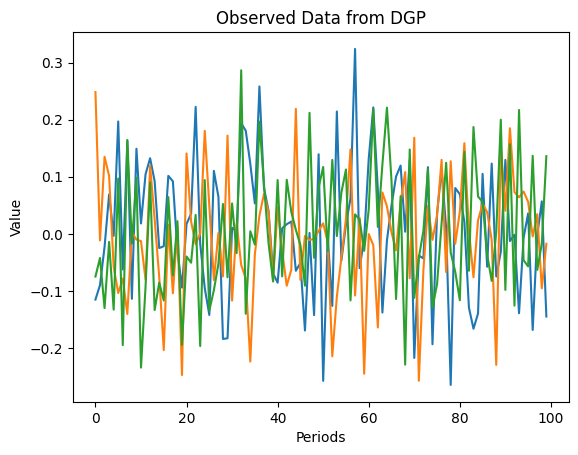

In [143]:
# simulate data from VAR process based on parameters and random coefficients
def VAR_data(V, O, T):
    A = np.random.uniform(low = -0.2, high = 0.2, size=(O, V, V)) # restricted to prevent explosive processes
    I = 0.2 * np.ones((O, V)) # initial periods of data

    observed_data = np.zeros((T+O, V))
    for t in range(0, T+O):
        if t < O:
            observed_data[t] = I[t]
        else:
            for o in range(1, O+1):
                observed_data[t] += A[o-1] @ observed_data[t-o, :] + np.random.normal(scale = 0.05, size = V) # VAR process
    observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

    observed_data = observed_data.drop(index=range(O)) # drop initial periods of data
    return observed_data.reset_index(drop = True), A

observed_data, A = VAR_data(V,O,T) # save the observed data and the matrices used to generate it (needed for true IRF)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from DGP")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating true IRFs

In [144]:
# true IRF from for a unit var1 shock
# this is what the econometrician is trying to estimate from observed data
def true(V, O, q, A):
    shock = np.zeros(V)
    shock[2] = 1 # shock variable 3
    irf = np.zeros((q+1, V))
    for t in range(q+1):
        if t == 0:
            irf[t] = shock
        else:
            for o in range(1, O+1):
                if t-o >= 0:
                    irf[t] += A[o-1] @ irf[t-o]

    return pd.DataFrame(irf, columns=[f'var{j}_shock1' for j in range(1, V+1)])

true_irf = true(V,O,q,A)

### Estimating the impulse responses

In [145]:
# VAR estimation of IRFs
var_mod = VAR(observed_data)
var_fit = var_mod.fit(O)
var_irfs = var_fit.irf(periods = q).irfs
var_beta = pd.DataFrame(var_irfs[:,:,2])

# LP/SLP estimation of IRFs
LP_mod = SmoothLocalProjections(observed_data, shock = "var3", endog = None, shock_exo = True, p = O, H = q)
LP_fit = LP_mod.LP()
SLP_fit = LP_mod.SLP()

LP_beta = pd.DataFrame(LP_fit.beta)
SLP_beta = pd.DataFrame(SLP_fit.beta)

### Plots

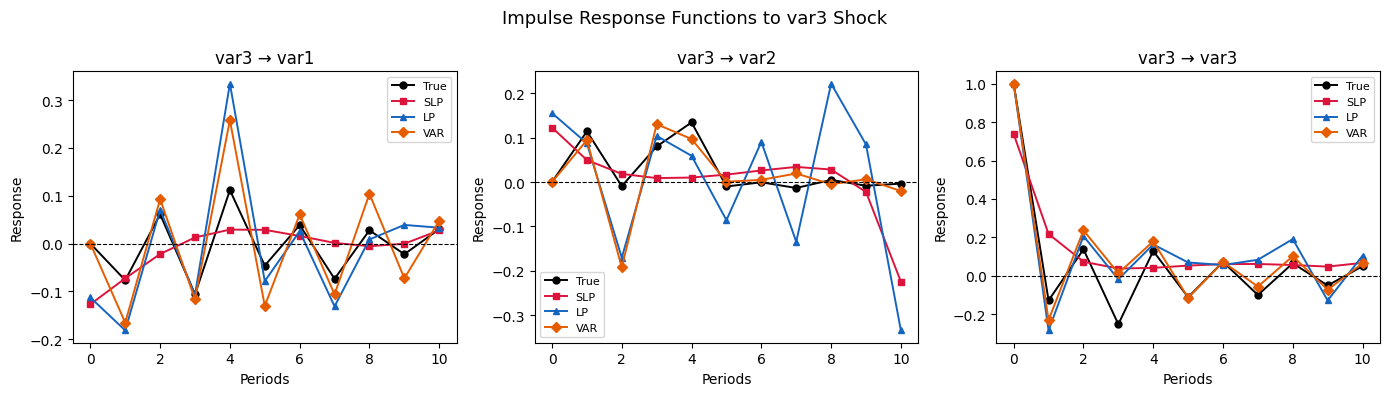

In [146]:
plot_irf_combined(true_irf, var_beta, LP_beta, SLP_beta)

### Discussion
The accuracy of these estimation procedures can be compared by calculating the mean squared error (MSE) of each.

In [147]:
print(f"MSE of VAR IRF: {np.mean((true_irf.values - var_beta.values)**2)}")
print(f"MSE of LP IRF: {np.mean((true_irf.values - LP_beta.values)**2)}")
print(f"MSE of SLP IRF: {np.mean((true_irf.values - SLP_beta.values)**2)}")

MSE of VAR IRF: 0.005589389588518953
MSE of LP IRF: 0.015434822099357792
MSE of SLP IRF: 0.015113042410580382


In order to ensure that this result is not due to the specific pattern of shocks and coefficients drawn the procedure should be average over multiple iterations.

In [148]:
# calculating the average mean squared error (MSE) over 500 simulations
var_MSE = np.zeros(500)
LP_MSE = np.zeros(500)
SLP_MSE = np.zeros(500)

for i in range(500):
    observed_data, A = VAR_data(V,O,T)
    true_irf = true(V,O,q,A)
    
    var_mod = VAR(observed_data)
    results = var_mod.fit(O)
    var_irfs = results.irf(periods=q).irfs
    var_beta = pd.DataFrame(var_irfs[:,:,0])

    LP_mod = SmoothLocalProjections(observed_data, "var3", None, True, O, q)
    LP_beta = pd.DataFrame(LP_mod.LP().beta)
    SLP_beta = pd.DataFrame(LP_mod.SLP().beta)

    var_MSE[i] = np.mean((true_irf.values - var_beta.values)**2)
    LP_MSE[i] = np.mean((true_irf.values - LP_beta.values)**2)
    SLP_MSE[i] = np.mean((true_irf.values - SLP_beta.values)**2)

avg_var_MSE = np.mean(var_MSE)
avg_LP_MSE = np.mean(LP_MSE)
avg_SLP_MSE = np.mean(SLP_MSE)

print(f"Average MSE of VAR IRFs over 500 simulations: {avg_var_MSE:.5f}")
print(f"Average MSE of LP IRFs over 500 simulations: {avg_LP_MSE:.5f}")
print(f"Average MSE of SLP IRFs over 500 simulations: {avg_SLP_MSE:.5f}")

Average MSE of VAR IRFs over 500 simulations: 0.07779
Average MSE of LP IRFs over 500 simulations: 0.01451
Average MSE of SLP IRFs over 500 simulations: 0.01163


Also of interest is how SLP accuracy changes as a function of the smoothing parameter $\lambda$. The default value is $\lambda = 1$.

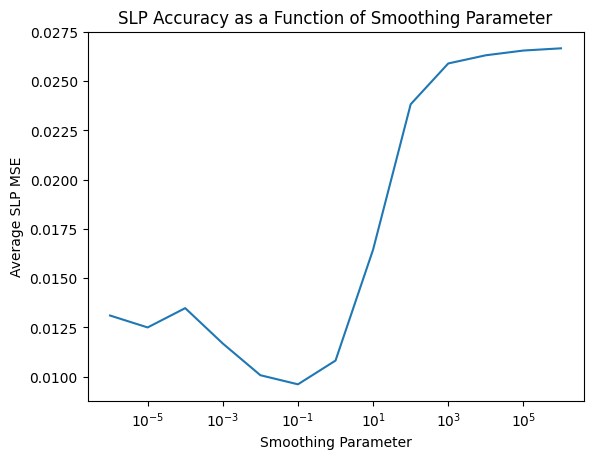

In [149]:
# evaluating how SLP MSE changes with smoothing parameter
SLP_MSE_lam = np.zeros((13,2))

for i in range(13):
    SLP_MSE = np.zeros(125)

    for j in range(125):
        observed_data, A = VAR_data(V,O,T)
        true_irf = true(V,O,q,A)

        LP_mod = SmoothLocalProjections(observed_data, "var3", None, True, O, q)
        SLP_beta = pd.DataFrame(LP_mod.SLP(lam = 10**(i-6)).beta) # smoothing parameter values between 10^-6 and 10^6

        SLP_MSE[j] = np.mean((true_irf.values - SLP_beta.values)**2)

    SLP_MSE_lam[i,0] = np.mean(SLP_MSE)
    SLP_MSE_lam[i,1] = 10**(i-6)

SLP_MSE_lam = pd.DataFrame(SLP_MSE_lam)

plt.plot(SLP_MSE_lam[1], SLP_MSE_lam[0])
plt.xlabel("Smoothing Parameter")
plt.ylabel("Average SLP MSE")
plt.title("SLP Accuracy as a Function of Smoothing Parameter")
plt.xscale('log')
plt.show()

The SLP MSE has a local minimum at $\lambda = 10^{-1}$ and sharply increases for higher values. Given that the underlying DGP is extremely jagged it makes sense for the optimal smoothing parameter to be low.